In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate

df = pd.read_csv('SeoulBikeData.csv')
df = df.drop(columns=df.select_dtypes(include=object))

X = df.drop(columns='Rented Bike Count')
Y = df['Rented Bike Count']

Definindo $\lambda$ (Embora haja bibliotecas prontas para definir o parâmetro, resolvi definir manualmente a primeira vez por fins didáticos)

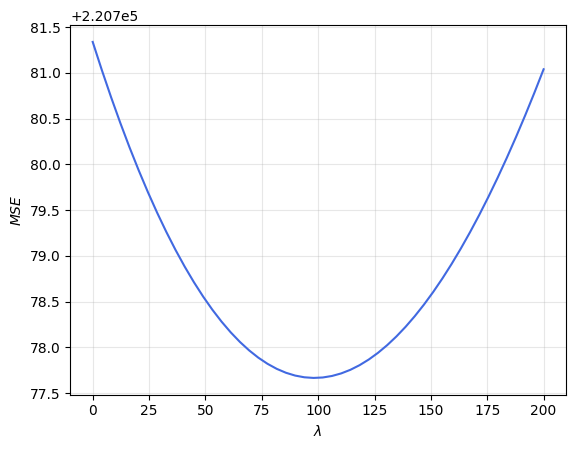

In [19]:
lamb = np.linspace(0,200,50)

erros = []

for i in range(len(lamb)):

    model = Ridge(alpha=lamb[i])
    cv = KFold(n_splits=10,shuffle=True,random_state=0)

    mse = cross_validate(model,X,Y,cv=cv,scoring='neg_mean_squared_error')

    erros.append(-mse['test_score'].mean())

plt.figure()
plt.grid(alpha=0.3)
plt.plot(lamb,erros,color='royalblue')
plt.ylabel(r'$MSE$')
plt.xlabel(r'$\lambda$')
#plt.axvline(X=lamb[erros.min()],ls='--',color='black')
plt.show()